<a href="https://colab.research.google.com/github/Hannessschool/Information-vix/blob/main/Project_InfoViz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##filuppladdning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


url_22 = "https://raw.githubusercontent.com/Hannessschool/Information-vix/Proect_info_viz/el_konsumption_012022.csv"
url_23 = "https://raw.githubusercontent.com/Hannessschool/Information-vix/Proect_info_viz/el_konsumption_012023.csv"
url_24 = "https://raw.githubusercontent.com/Hannessschool/Information-vix/Proect_info_viz/el_konsumption_012024.csv"

url_daily = "https://raw.githubusercontent.com/Hannessschool/Information-vix/Proect_info_viz/el_konsumption_072023_062024_daglig.csv"
url_monthly = "https://raw.githubusercontent.com/Hannessschool/Information-vix/Proect_info_viz/el_konsumption_072023_062024_m%C3%A5natlig.csv"

df_jan22_datasheet = pd.read_csv(url_22, encoding="latin1")
df_jan23_datasheet = pd.read_csv(url_23, encoding="latin1")
df_jan24_datasheet = pd.read_csv(url_24, encoding="latin1")

df_daily_datasheet = pd.read_csv(url_daily, encoding="latin1")
df_monthly_datasheet = pd.read_csv(url_monthly, encoding="latin1")


##df_daily_datasheet = pd.read_csv("el_konsumption_072023_062024_daglig.csv", sep=",", encoding='latin1')
##df_monthly_datasheet = pd.read_csv("el_konsumption_072023_062024_månatlig.csv", sep=",", encoding='latin1')
##df_jan22_datasheet = pd.read_csv("el_konsumption_012022.csv", sep=",", encoding='latin1')
##df_jan23_datasheet = pd.read_csv("el_konsumption_012023.csv", sep=",", encoding='latin1')
##df_jan24_datasheet = pd.read_csv("el_konsumption_012024.csv", sep=",", encoding='latin1')


df_daily_datasheet.head()
df_monthly_datasheet.head()
df_jan22_datasheet.head()
df_jan23_datasheet.head()
df_jan24_datasheet.head()

,Time period,Electricity - Total consumption (kWh),Distribution - Basic charge (euro),Distribution - Electricity tax (euro),Distribution - VAT (euro),Distribution fee (euro),Spot price (c/kWh),Temperature (°C),Total (euro)
0,01.01.2024,5.09,0.24,0.11,0.13,0.17,5.59,-20.20,0.65
1,02.01.2024,6.77,0.24,0.15,0.15,0.22,21.30,-25.80,0.76
2,03.01.2024,8.98,0.24,0.20,0.18,0.30,12.42,-25.35,0.92
3,04.01.2024,8.45,0.24,0.19,0.17,0.28,28.02,-26.94,0.88
4,05.01.2024,8.39,0.24,0.19,0.17,0.28,109.97,-27.56,0.88


In [ ]:
# Install Panel for creating an interactive dashboard
%pip install panel

In [ ]:
## konsumptionsjämförande barchart(första i ordning vertikalt av 4 delar)


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def create_bar_chart1(nro, df_daily_datasheet):




















  return fig


**Sebastian sätt din första plot hit**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


##piechart (andra i ordning vertikalt av 4 delar, är färdig nu)

def create_pie_chart(nro, df_daily_datasheet):

  row = df_daily_datasheet.loc[df_daily_datasheet["Month classification"] == nro]

  distribution_base = row["Distribution - Basic charge (euro)"].sum()
  el_tax = row["Distribution - Electricity tax (euro)"].sum()
  vat_tax = row["Distribution - VAT (euro)"].sum()
  distribution_fee = row["Distribution fee (euro)"].sum()

  values = [distribution_base, el_tax, vat_tax, distribution_fee]
  labels = ["Distribution base cost", "Electricity tax", "VAT tax", "Distribution fee"]

  fig, ax = plt.subplots(figsize=(10, 10))

  def autopct_format(values):
      def inner(pct):
          total = sum(values)
          percent = pct * total / 100
          return f"{pct:.1f}%\n{percent:.2f} €"
      return inner

  wedges = ax.pie(
      values,
      labels=None,
      wedgeprops={"width": 0.3},
      autopct=autopct_format(values),
      startangle=90
  )[0]

  ax.legend(
      wedges,
      labels,
      title = "Cost breakdown",
      loc = "center right",
      bbox_to_anchor = (1, 1)
  )

  filtering = df_daily_datasheet['Month classification'] == nro

  total_cost = (
      df_daily_datasheet.loc[filtering, "Distribution - Basic charge (euro)"].sum() +
      df_daily_datasheet.loc[filtering, "Distribution - Electricity tax (euro)"].sum() +
      df_daily_datasheet.loc[filtering,"Distribution - VAT (euro)"].sum() +
      df_daily_datasheet.loc[filtering, "Distribution fee (euro)"].sum()
  )

  average_cost = (
      df_daily_datasheet.loc[filtering, "Distribution - Basic charge (euro)"].mean() +
      df_daily_datasheet.loc[filtering, "Distribution - Electricity tax (euro)"].mean() +
      df_daily_datasheet.loc[filtering,"Distribution - VAT (euro)"].mean() +
      df_daily_datasheet.loc[filtering, "Distribution fee (euro)"].mean()
  )

  average_usage = df_daily_datasheet.loc[filtering, "Electricity - Total consumption (kWh)"].mean()

  month_names = [
      "23 July", "23 Aug", "23 Sept", "23 Oct",
      "23 Nov", "23 Dec",
      "24 Jan", "24 Feb", "24 Mar",
      "24 Apr", "24 May", "24 June"
  ]

  ax.set_title(f"Cost breakdown for '{month_names[nro - 1]}")
  ax.text(0, 0, f" Total cost {total_cost:.2f} €", ha='center', va='center', fontsize=18)
  ax.text(2.5,0.5, f"Average cost per day: \n {average_cost:.2f} €, \n Average usage per day: \n {average_usage: .2f} kWh, \n Average cost per consumed kWh: \n {average_cost/average_usage: .2f} €/kWh", ha='right', va='center', fontsize=18)

  ax.set_ylabel("")
  return fig

In [ ]:
## konsumptionsjämförande barplot med tidigare år, samma tid (tredje i ordning vertikalt av 4 delar, är färdig nu)¨

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def create_bar_chart2(df_jan22_datasheet, df_jan23_datasheet, df_jan24_datasheet):














  return fig


**Sebastian sätt din andra plot hit**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## temperaturjämförande barplot (fjärde i ordning vertikalt av 4 delar, är färdig nu)

def create_dual_axis_plot(nro, plot_type, df_daily_datasheet):

  row=df_daily_datasheet.loc[df_daily_datasheet["Month classification"] == nro]

  dates = row['Time period']
  electricity_consumption = row["Electricity - Total consumption (kWh)"]
  cost = row['Total (euro)']
  temperature = row["Temperature (°C)"]

  x_values = dates

  if plot_type == 1:
    left_values = electricity_consumption
  elif plot_type == 2:
    left_values = cost

  right_values = temperature

  x = x_values
  fig, ax_left = plt.subplots(figsize=(20,10))
  plt.xticks(rotation=90, fontsize=12, fontweight='bold')

  if plot_type == 1:
    ax_left.bar(x, left_values, color="skyblue", label="Consumption (bars)")
    ax_left.set_ylabel("Total daily consumption in kWh", fontsize=14)
  elif plot_type == 2:
    ax_left.bar(x, left_values, color="skyblue", label="Cost (bars)")
    ax_left.set_ylabel("Total daily electricity cost in €", fontsize=14)
  ax_left.tick_params(axis='y', labelsize=12)

  ax_right = ax_left.twinx()
  ax_right.plot(x, right_values, color="red", marker="o", label="Temperature (line)")
  ax_right.set_ylabel("Average daily temperature in °C", fontsize=14)
  ax_right.tick_params(axis='y', labelsize=12)

  month_names = [
      "23 July", "23 Aug", "23 Sept", "23 Oct",
      "23 Nov", "23 Dec",
      "24 Jan", "24 Feb", "24 Mar",
      "24 Apr", "24 May", "24 June"
  ]

  lines, labels = ax_left.get_legend_handles_labels()
  lines2, labels2 = ax_right.get_legend_handles_labels()

  ax_left.legend(lines + lines2, labels + labels2,
                 title="Bar and line explanations",
                 loc="upper right",
                 bbox_to_anchor=(1.20, 1))

  if plot_type == 1:
    ax_left.set_title(f"Daily consumption to average temperature, '{month_names[nro - 1]}", fontsize=16)
  elif plot_type == 2:
    ax_left.set_title(f"Daily cost to average temperature, '{month_names[nro - 1]}", fontsize=16)

  return fig

Choose the month you want to observe from 1 to 12, equalling July '23 to June '24 respectively. Input numbers only.
Further example on input: January 2026 would equal an answer of 7. 3
For the temperature firgure: choose if you want to compare it to Consumption or Cost data. Choose 1 for consumption data, 2 for cost data. 2


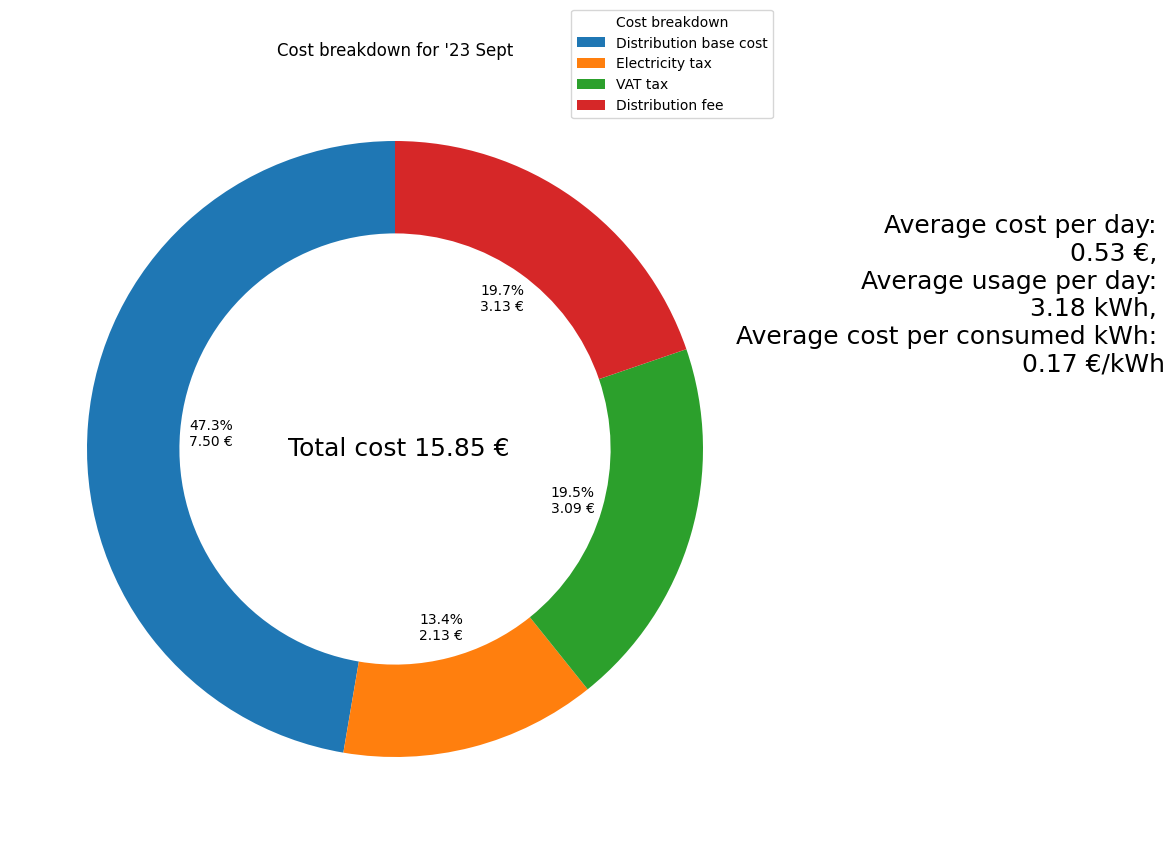

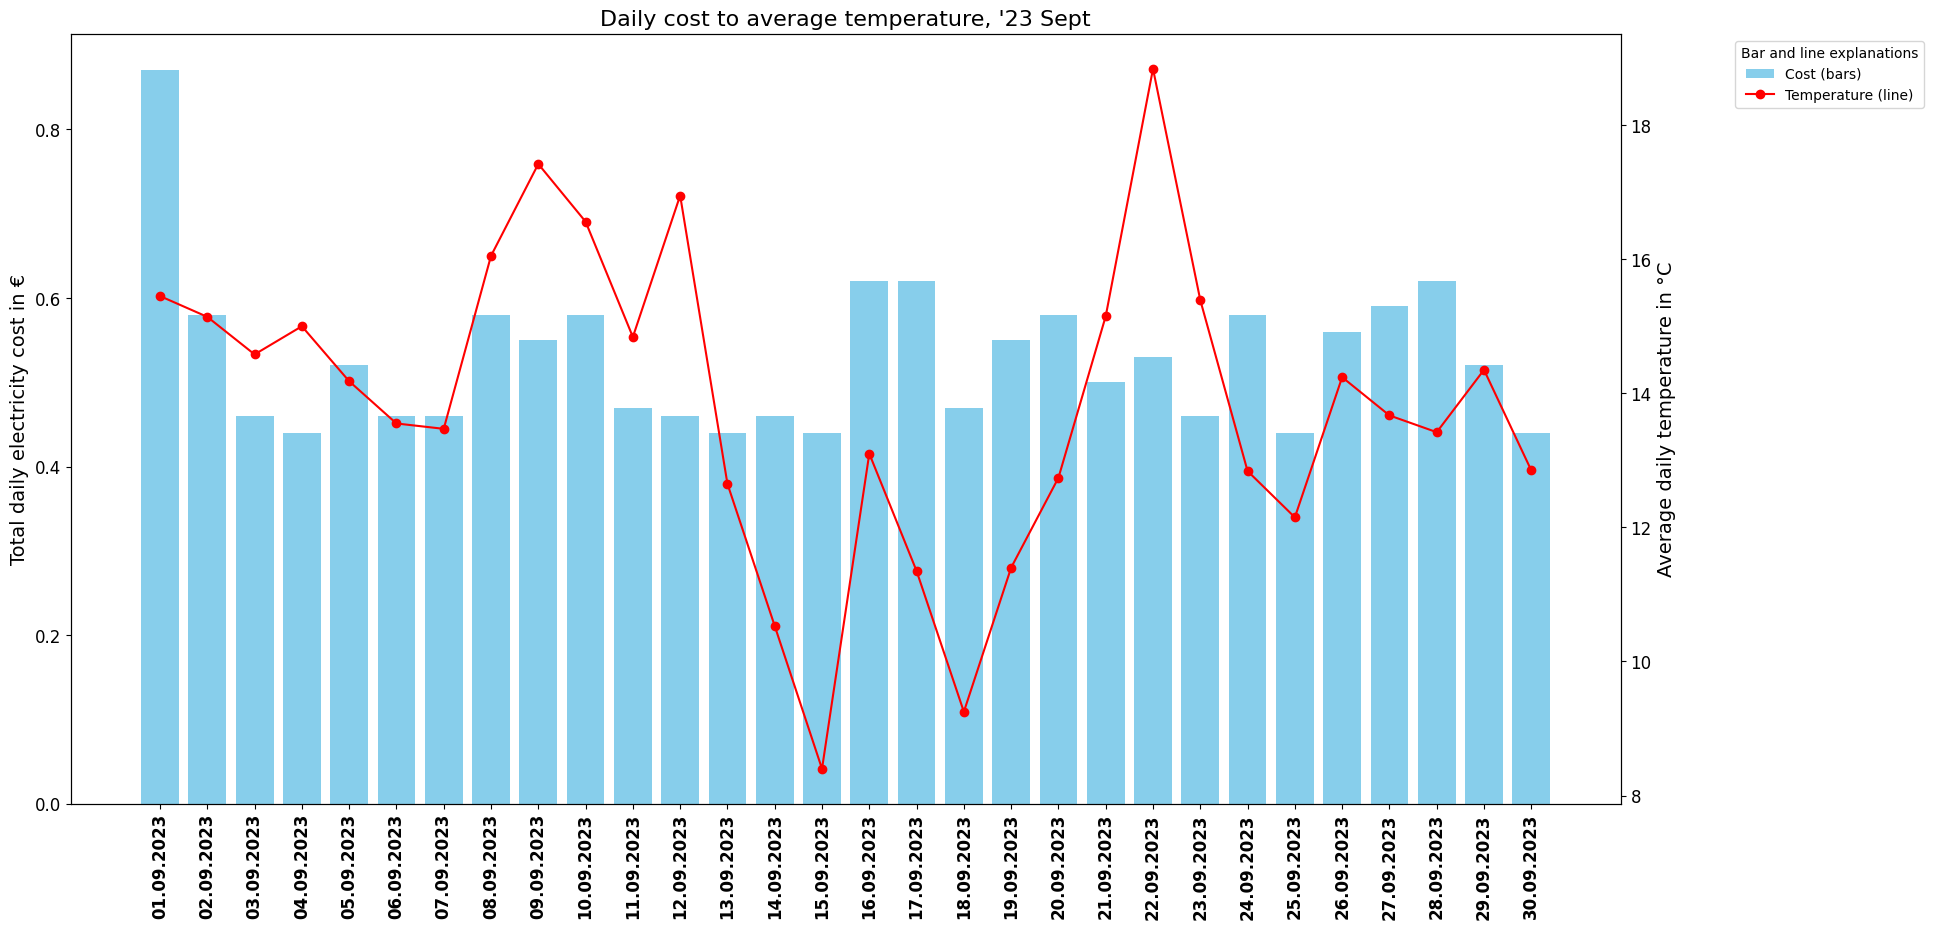

<Figure size 4000x4000 with 0 Axes>

In [ ]:
##Dashboard execution codespace (inte färdig)
while True:
  try:
    nro = int(input("Choose the month you want to observe from 1 to 12, equalling July '23 to June '24 respectively. Input numbers only.\nFurther example on input: January 2026 would equal an answer of 7. "))
    if(1 <= (nro) <= 12):
      break
    else:
      print("Invalid input. Try again.")
  except ValueError:
    print("Invalid input. Please enter a NUMBER.")

while True:
  try:
    plot_type = int(input("For the temperature firgure: choose if you want to compare it to Consumption or Cost data. Choose 1 for consumption data, 2 for cost data. "))
    if(1 <= (plot_type) <= 2):
      break
    else:
      print("Invalid input. Please choose either 1 or 2.")
  except ValueError:
    print("Invalid input. Please choose either 1 or 2.")

##Generate the plots
##bar_consumption_graph_fig = create_bar_chart1(nro, df_daily_datasheet)  ##Sebastian graf 1

pie_chart_fig = create_pie_chart(nro, df_daily_datasheet)

##bar_consumption_past_years_fig = create_bar_chart2(df_jan22_datasheet, df_jan23_datasheet, df_jan24_datasheet)  ##Sebastian graf 2

dual_axis_fig = create_dual_axis_plot(nro, plot_type, df_daily_datasheet)

# Display the plots vertically
plt.figure(figsize=(40, 40)) # Create a dummy figure to hold all plots

##display(bar_consumption_graph_fig)     ##Sebastian graf 1

display(pie_chart_fig)

##display(bar_consumption_past_years_fig)    ##Sebastian graf 2

display(dual_axis_fig)

# Close the figures to prevent them from being displayed again if the cell is re-executed
##plt.close(bar_consumption_graph_fig)   ##Sebastian graf 1
plt.close(pie_chart_fig)
##plt.close(bar_consumption_past_years_fig)  ##Sebastian graf 2
plt.close(dual_axis_fig)